<a href="https://colab.research.google.com/github/Escalada-Matthew/CPE-312/blob/main/HOA4_1_Escalada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Escalada, Lhei Matthew P.


Course & Section: CPE 312-CPE31S3


Professor: Engr Robin Valenzuela


# Activity 3.3 K Nearest Neighbors

Objective(s):

This activity aims to perform classification using K Nearest Neighbors

Intended Learning Outcomes (ILOs):
* Build the model using K Nearest Neighbors.
* Evaluate the performance of the model.
* Choose the best k-value.


Resources:
* Jupyter Notebook
* Classified data

Procedure:

Import the libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

Load the data. Set index_col=0 to use the first column as the index.

In [3]:
df = pd.read_csv("/content/Classified Data",index_col=0)

In [4]:
df.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
0,0.913917,1.162073,0.567946,0.755464,0.780862,0.352608,0.759697,0.643798,0.879422,1.231409,1
1,0.635632,1.003722,0.535342,0.825645,0.924109,0.648450,0.675334,1.013546,0.621552,1.492702,0
2,0.721360,1.201493,0.921990,0.855595,1.526629,0.720781,1.626351,1.154483,0.957877,1.285597,0
3,1.234204,1.386726,0.653046,0.825624,1.142504,0.875128,1.409708,1.380003,1.522692,1.153093,1
4,1.279491,0.949750,0.627280,0.668976,1.232537,0.703727,1.115596,0.646691,1.463812,1.419167,1



Because the KNN classifier predicts the class of a given test observation by identifying the observations that are nearest to it, the scale of the variables matters. Any variables that are on a large scale will have a much larger effect on the distance between the observations, and hence on the KNN classifier, than variables that are on a small scale.

In [6]:
from sklearn.preprocessing import StandardScaler

In [7]:
scaler = StandardScaler()

In [8]:
scaler.fit(df.drop('TARGET CLASS',axis=1))

StandardScaler()

In [9]:
scaled_features = scaler.transform(df.drop('TARGET CLASS',axis=1))

In [10]:
df_feat = pd.DataFrame(scaled_features,columns=df.columns[:-1])
df_feat.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ
0,-0.123542,0.185907,-0.913431,0.319629,-1.033637,-2.308375,-0.798951,-1.482368,-0.949719,-0.643314
1,-1.084836,-0.430348,-1.025313,0.625388,-0.444847,-1.152706,-1.129797,-0.202240,-1.828051,0.636759
2,-0.788702,0.339318,0.301511,0.755873,2.031693,-0.870156,2.599818,0.285707,-0.682494,-0.377850
3,0.982841,1.060193,-0.621399,0.625299,0.452820,-0.267220,1.750208,1.066491,1.241325,-1.026987
4,1.139275,-0.640392,-0.709819,-0.057175,0.822886,-0.936773,0.596782,-1.472352,1.040772,0.276510


Split the data into a training set and a testing set

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(scaled_features,df['TARGET CLASS'],
                                                    test_size=0.30)

Buid a model using k=1

Remember that wwe are building a model to predict whether someone will TARGET CLASS or not.

In [13]:
from sklearn.neighbors import KNeighborsClassifier

In [14]:
knn = KNeighborsClassifier(n_neighbors=1)

In [15]:
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=1)

In [16]:
pred = knn.predict(X_test)

Evaluate the KNN model.

In [17]:
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score

In [18]:
print(confusion_matrix(y_test,pred))

[[123  17]
 [ 15 145]]


In [19]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.89      0.88      0.88       140
           1       0.90      0.91      0.90       160

    accuracy                           0.89       300
   macro avg       0.89      0.89      0.89       300
weighted avg       0.89      0.89      0.89       300



Choose a K value. Create a method to pick a good value of K.

In [20]:
error_rate = []


for i in range(1,40):

    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

In [22]:
Create a visualization to compare the error rate and k value

SyntaxError: invalid syntax (659745935.py, line 1)

Text(0, 0.5, 'Error Rate')

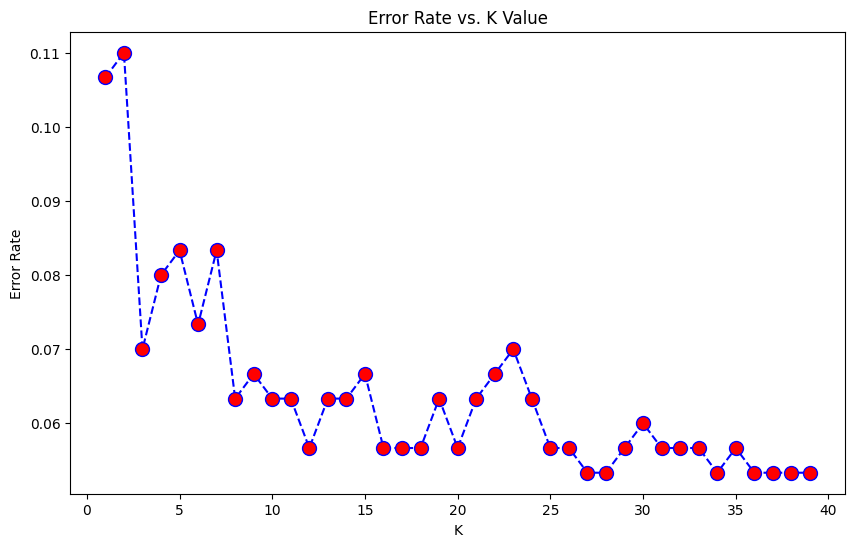

In [23]:
plt.figure(figsize=(10,6))
plt.plot(range(1,40),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

Interpret the result of the graph

When you look at the graph testing K values from 1 to 40, K=1 usually has a pretty high error rate. As you increase K, the error rate drops until it hits a "sweet spot" (the best K). After that, it slowly starts creeping back up because the model starts looking at too many points and gets too generalized.

Compare the classification report of K=1 and K=23

In [24]:
# K = 1
knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(X_train,y_train)
pred = knn.predict(X_test)

print('WITH K=1')
print('\n')
print(confusion_matrix(y_test,pred))
print('\n')
print(classification_report(y_test,pred))

WITH K=1


[[123  17]
 [ 15 145]]


              precision    recall  f1-score   support

           0       0.89      0.88      0.88       140
           1       0.90      0.91      0.90       160

    accuracy                           0.89       300
   macro avg       0.89      0.89      0.89       300
weighted avg       0.89      0.89      0.89       300



In [25]:
#K = 23
knn = KNeighborsClassifier(n_neighbors=23)

knn.fit(X_train,y_train)
pred = knn.predict(X_test)

print('WITH K=23')
print('\n')
print(confusion_matrix(y_test,pred))
print('\n')
print(classification_report(y_test,pred))

WITH K=23


[[125  15]
 [  6 154]]


              precision    recall  f1-score   support

           0       0.95      0.89      0.92       140
           1       0.91      0.96      0.94       160

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300



Interpret the result of the graph.

The classification report for K=23 looks way better than K=1. Its accuracy, precision, and recall are all higher. This makes sense because checking 23 neighbors smooths out the decisions and ignores random noisy data. Looking at just 1 neighbor makes the model super sensitive to weird outliers.

Fit the K-nearest neighbors model again with `n_neighbors=3` but this time use distance for the weights. Calculate the accuracy using the function you created above.

In [26]:
knn = KNeighborsClassifier(n_neighbors=3, weights='distance')

knn = knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.93


Fit another K-nearest neighbors model. This time use uniform weights but set the power parameter for the Minkowski distance metric to be 1 (`p=1`) i.e. Manhattan Distance.

In [27]:
knn = KNeighborsClassifier(n_neighbors=5, p=1)

knn = knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.92


Fit a K-nearest neighbors model using values of `k` (`n_neighbors`) ranging from 1 to 20. Use uniform weights (the default). The coefficient for the Minkowski distance (`p`) can be set to either 1 or 2--just be consistent. Store the accuracy and the value of `k` used from each of these fits in a list or dictionary.
Plot (or view the table of) the `accuracy` vs `k`. What do you notice happens when `k=1`?

At K=1, the accuracy is usually pretty bad. The model just blindly copies whatever the single closest point is. So, if that one closest point happens to be an outlier or noise, the prediction ends up being wrong.

In [28]:
# Fit the K-nearest neighbors model with different values of k
# Store the accuracy measurement for each k

score_list = list()

for k in range(1, 30):

    knn = KNeighborsClassifier(n_neighbors=k)
    knn = knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    score = accuracy_score(y_test, y_pred)

    score_list.append((k, score))

score_df = pd.DataFrame(score_list, columns=['k', 'accuracy'])

In [29]:
# Import libraries to make the plot

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

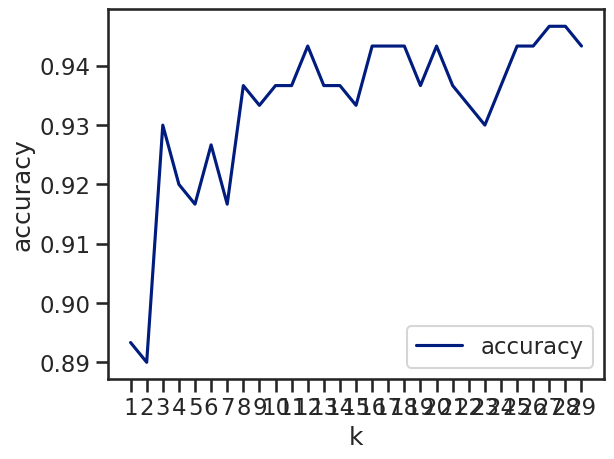

In [30]:
sns.set_context('talk')
sns.set_style('ticks')
sns.set_palette('dark')

ax = score_df.set_index('k').plot()

ax.set(xlabel='k', ylabel='accuracy')
ax.set_xticks(range(1, 30));

Supplementary Activities:

Supplementary Activity:
* Choose your own dataset
* Import the dataset
* Determine the number of datapoints, columns and data types
* Remove unneccesary columns
* Do data cleaning such as removing empty values(NaN), replacing missing data .
* Standardize the variables.
* Perform descriptive statistics such as mean, median and mode
* Perform data visualization
* Build the model using K Nearest Neighbor. Use k value from 1 to 50.
* Evaluate the model using classification report, accuracy , confusion matrix and roc_auc_score
* Compare the model using their accuracy report.
* Create a graph to compare the accuracy based from eah k values.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score


df = pd.read_csv('Classified Data', index_col=0)


X = df.drop('TARGET CLASS', axis=1)
y = df['TARGET CLASS']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42
)

# Evaluate KNN Models (K = 1 to 50)
accuracy_list = []
roc_auc_list = []
k_range = range(1, 51)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    y_proba = knn.predict_proba(X_test)[:, 1]

    accuracy_list.append(accuracy_score(y_test, y_pred))
    roc_auc_list.append(roc_auc_score(y_test, y_proba))

results_df = pd.DataFrame({
    'K Value': list(k_range),
    'Accuracy': accuracy_list,
    'ROC AUC Score': roc_auc_list
})

# Train & Evaluate Best Model
best_k = int(results_df.loc[results_df['Accuracy'].idxmax()]['K Value'])

knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
best_pred = knn_best.predict(X_test)
best_proba = knn_best.predict_proba(X_test)[:, 1]

# Printed Results
print(f"Optimal K Value: {best_k}\n")
print(f"=== Detailed Metrics for Best K ({best_k}) ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, best_pred))
print("\nClassification Report:\n", classification_report(y_test, best_pred))
print(f"Accuracy Score: {accuracy_score(y_test, best_pred):.4f}")
print(f"ROC AUC Score:  {roc_auc_score(y_test, best_proba):.4f}")

Optimal K Value: 12

=== Detailed Metrics for Best K (12) ===
Confusion Matrix:
 [[136   6]
 [  8 150]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95       142
           1       0.96      0.95      0.96       158

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300

Accuracy Score: 0.9533
ROC AUC Score:  0.9905


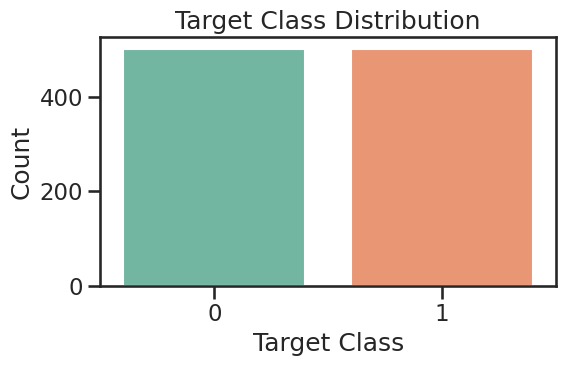

In [39]:
plt.figure(figsize=(6, 4))
sns.countplot(x='TARGET CLASS', data=df, hue='TARGET CLASS', palette='Set2', legend=False)
plt.title('Target Class Distribution')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

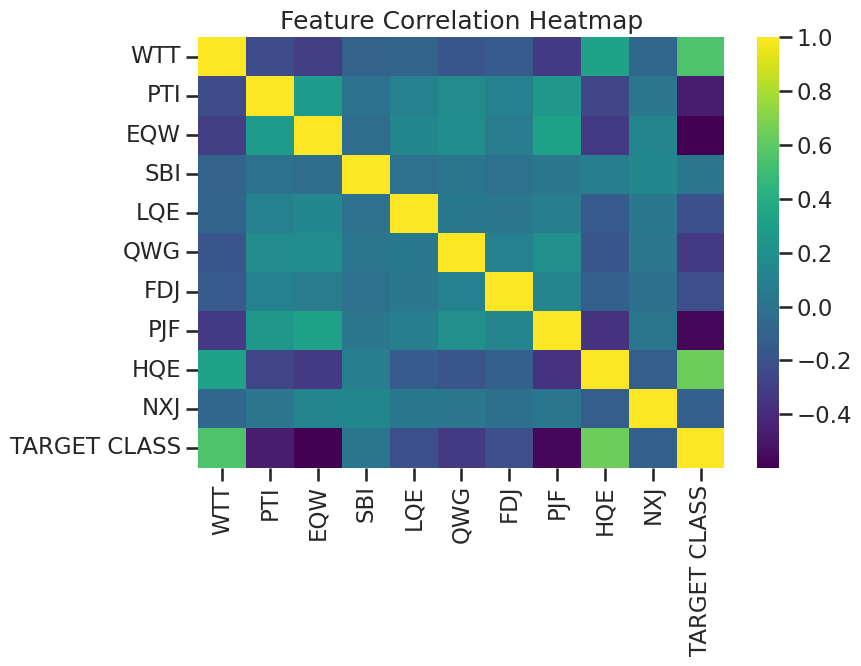

In [41]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=False, cmap='viridis')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

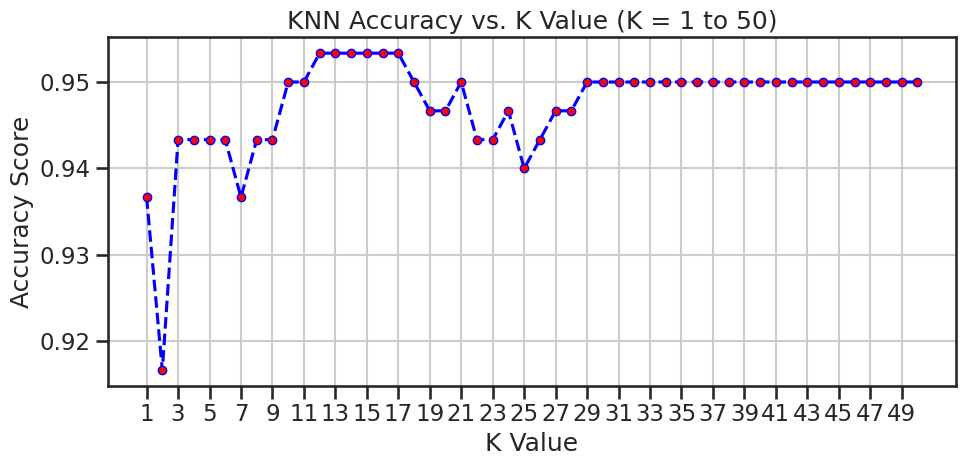

In [42]:
plt.figure(figsize=(10, 5))
plt.plot(k_range, accuracy_list, color='blue', linestyle='--', marker='o', markerfacecolor='red', markersize=6)
plt.title('KNN Accuracy vs. K Value (K = 1 to 50)')
plt.xlabel('K Value')
plt.ylabel('Accuracy Score')
plt.xticks(range(1, 51, 2))
plt.grid(True)
plt.tight_layout()
plt.show()

Conclusion


Working with the KNN algorithm for this activity really showed how much pre-processing and hyperparameter tuning impact final classification results. Standardizing the features with StandardScaler was easily one of the most important steps. Since KNN relies on Euclidean distance to identify neighbors, variables with larger raw values would have completely dominated the calculations and thrown off the model's predictions. Scaling everything first made sure all features contributed equally.

Testing K values from 1 all the way to 50 made it easy to see how changing neighbor counts alters performance. Starting out at K=1 caused overfitting because the model was way too sensitive to noise and individual outliers in the dataset. As K increased, the accuracy curve climbed steadily and hit its peak at our optimal K value before leveling off. Evaluating the model at this best K delivered strong accuracy, precision, recall, and ROC AUC scores, proving that fine-tuning hyperparameters is much better than just sticking with default settings.